# This Notebook Aims to Understand and Explore the Raw Dataset

## Importing


In [1]:
from pathlib import Path
import sys
root= Path.cwd().parent
sys.path.append(str(root))
from src.graph import univariate_plot, locations_scatter, correlation_heatmap, bivariate_plot
import pandas as pd

In [2]:
data = pd.read_csv('../data/raw/raw_data.csv')

## Dataset Overview

In [3]:
data.shape

(20640, 10)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
data['ocean_proximity'].mode()

0    <1H OCEAN
Name: ocean_proximity, dtype: object

## Handling Missing Values

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Missing values are only present in 'total_bedrooms' column

In [8]:
row_count = len(data)
missing_count = data['total_bedrooms'].isnull().sum()
print(f"{missing_count*100/row_count}% of rows have a missing value in the bedroom count column")

1.002906976744186% of rows have a missing value in the bedroom count column


In [9]:
missing_count

np.int64(207)

Replace these values by the median (since the ratio is very low and the column is right skewed)

In [10]:
data["total_bedrooms"]= data["total_bedrooms"].fillna( data["total_bedrooms"].median())

In [11]:
data.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
15529,-117.11,33.15,14.0,8374.0,1407.0,2916.0,1295.0,4.7019,191100.0,<1H OCEAN
15614,-122.41,37.81,25.0,1178.0,545.0,592.0,441.0,3.6728,500001.0,NEAR BAY
488,-122.26,37.86,52.0,2888.0,604.0,1253.0,538.0,3.3893,241700.0,NEAR BAY
14009,-117.19,32.75,52.0,1388.0,213.0,513.0,211.0,6.1309,411600.0,NEAR OCEAN
1828,-122.31,37.92,12.0,1895.0,600.0,983.0,519.0,2.5000,195800.0,NEAR BAY


Looking more onto the values of ocean_proximity

In [12]:
data["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [19]:
near_bay = (data["ocean_proximity"] == 'NEAR BAY').sum()
ocean_1h = (data["ocean_proximity"] == '<1H OCEAN').sum()
inland = (data["ocean_proximity"] == 'INLAND').sum()
near_ocean = (data["ocean_proximity"] == 'NEAR OCEAN').sum()
island = (data["ocean_proximity"] == 'ISLAND').sum()

In [20]:
print('Near Bay observations: ', near_bay)
print('<1h ocean observations: ', ocean_1h)
print('Inland observations: ', inland)
print('Near Ocean observations: ', near_ocean)
print('island observations: ', island)

Near Bay observations:  2290
<1h ocean observations:  9136
Inland observations:  6551
Near Ocean observations:  2658
island observations:  5


Looking for duplicates

In [14]:
data.duplicated().sum()

np.int64(0)

## Plotting

Plotting Histograms and BoxPlots

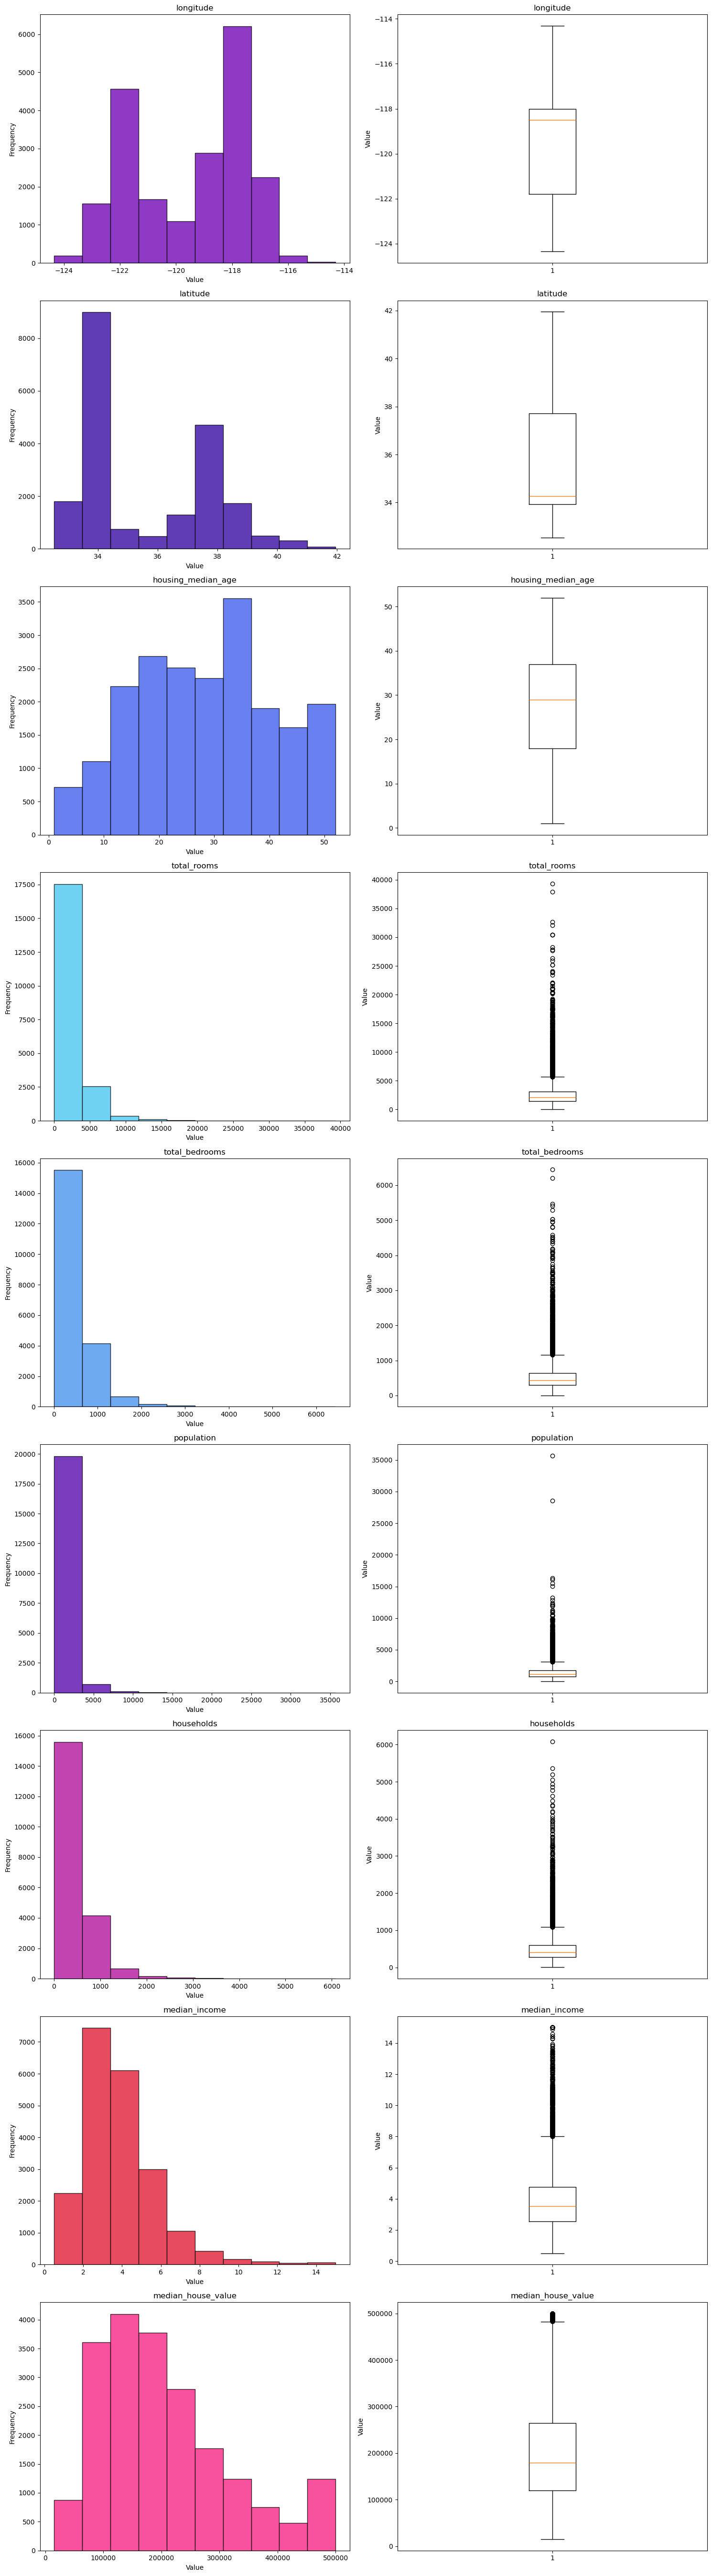

In [15]:
univariate_plot(data, 0 ,9)

Plotting location scatter plot
on the x-axis: longitude
on the y-axis: latitude

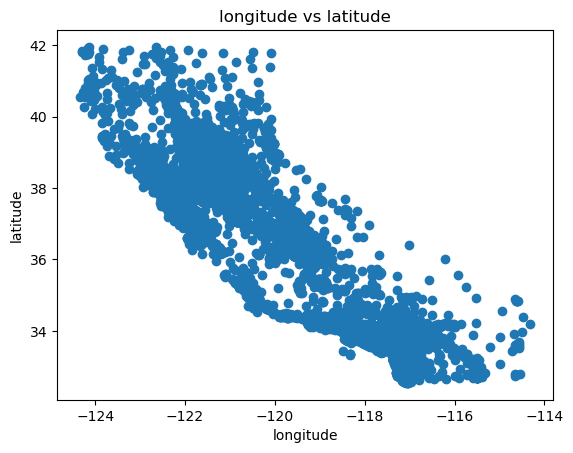

In [16]:
locations_scatter(data)

Plotting correlation heatmap

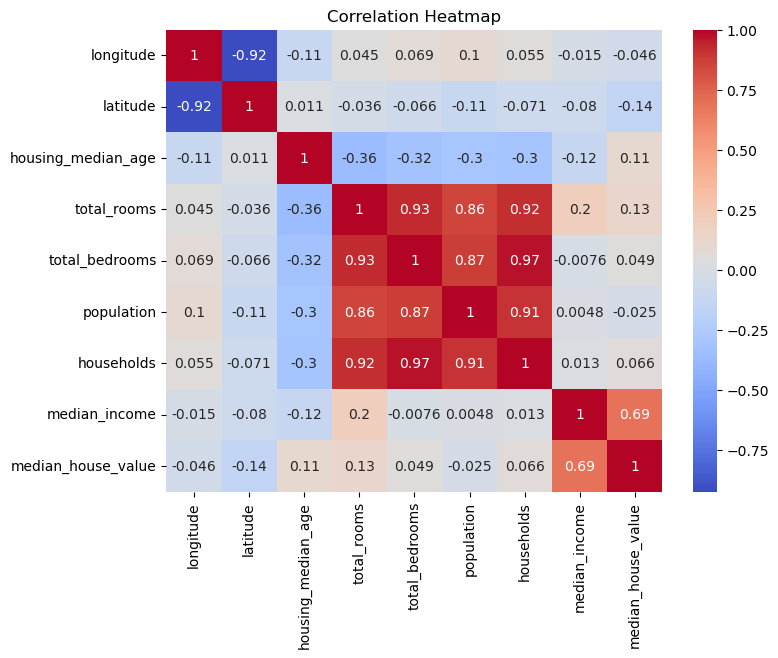

In [17]:
correlation_heatmap(data, 0,9)

Plotting scatter plots between every numerical column and the target column

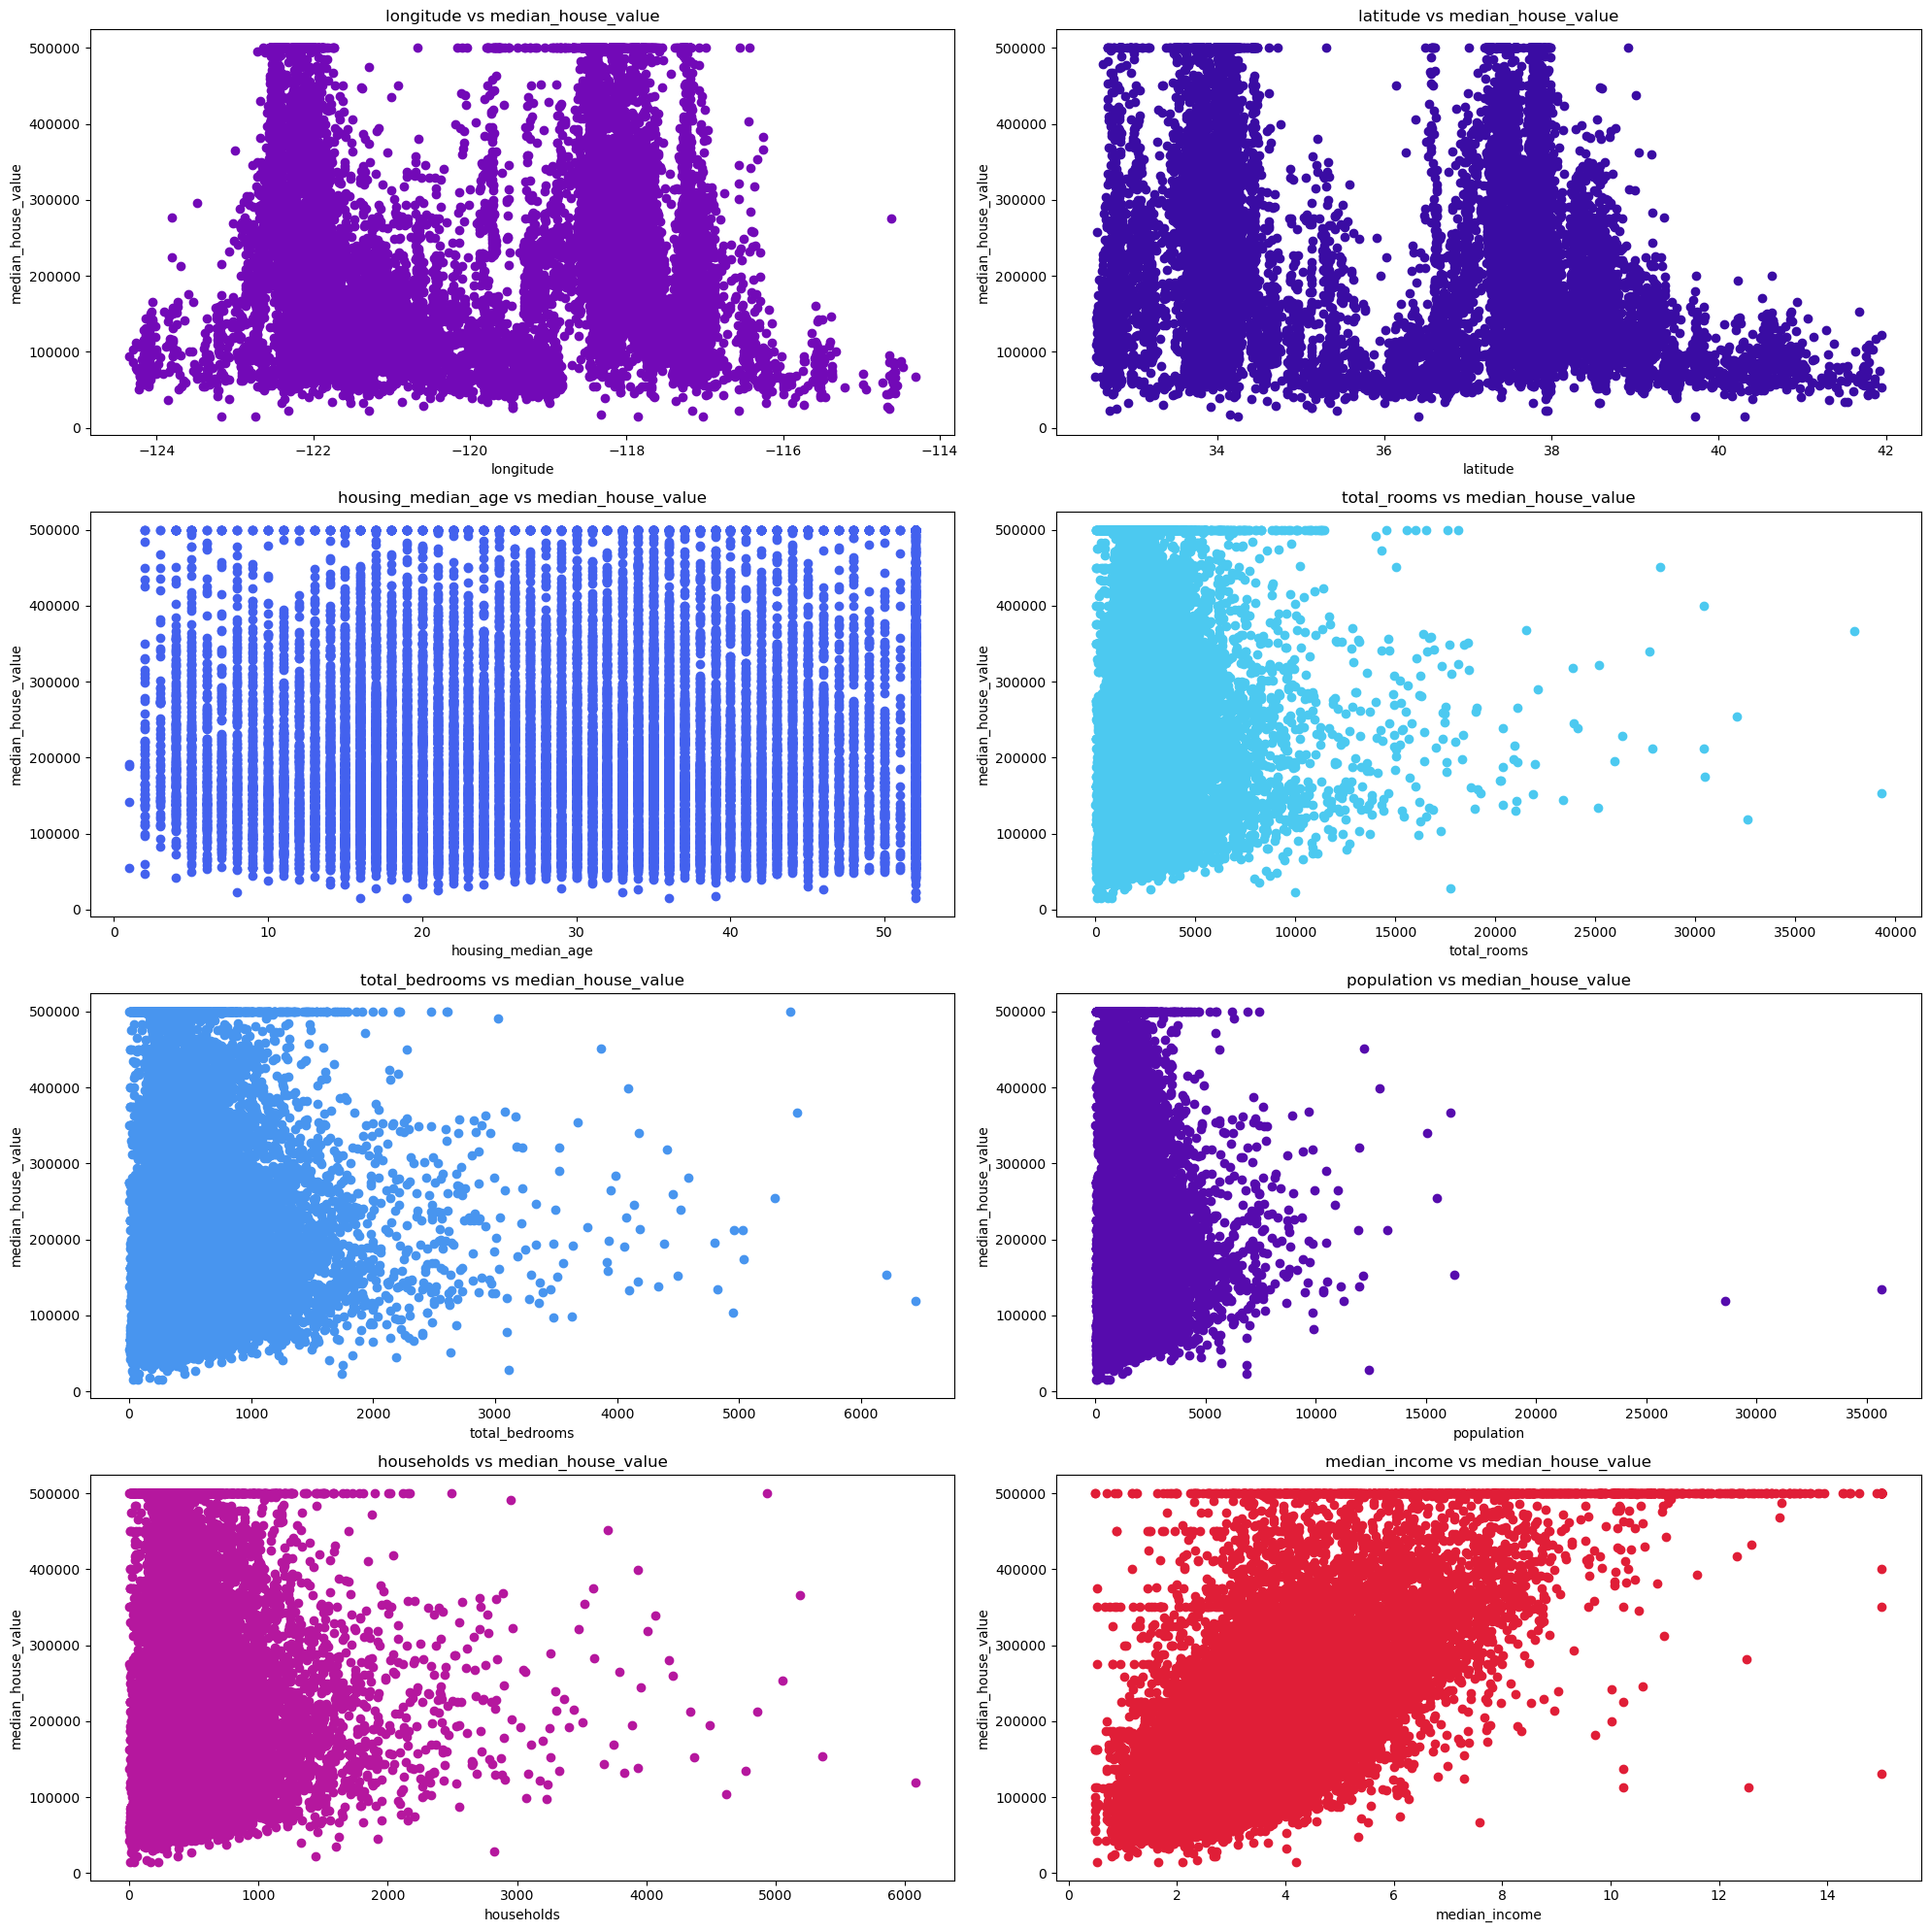

In [18]:
bivariate_plot(data)